# Explainable AI using SHAP

This notebook explains the predictions made by the trained XGBoost model using SHAP (SHapley Additive exPlanations). SHAP provides both global and local interpretability by identifying the contribution of each feature towards the phishing prediction.

In [3]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

d:\5thSemProject\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Model 

In [4]:
xgb = joblib.load("../models/xgboost_model.pkl")

# Load Dataset

In [5]:
df = pd.read_csv("cleaned_dataset.csv")

X = df.drop(columns=['URL','Domain','TLD','Title','label'])
y = df['label']

# Create Explainer

In [6]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

# Global Importance

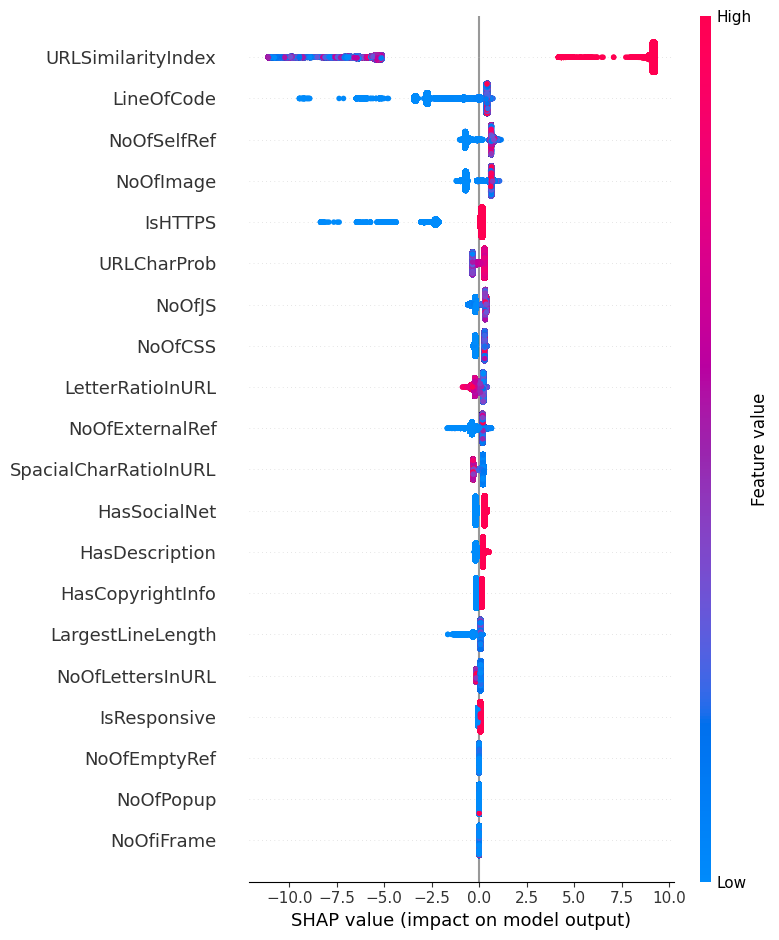

In [7]:
shap.summary_plot(shap_values, X)

# Bar Plot

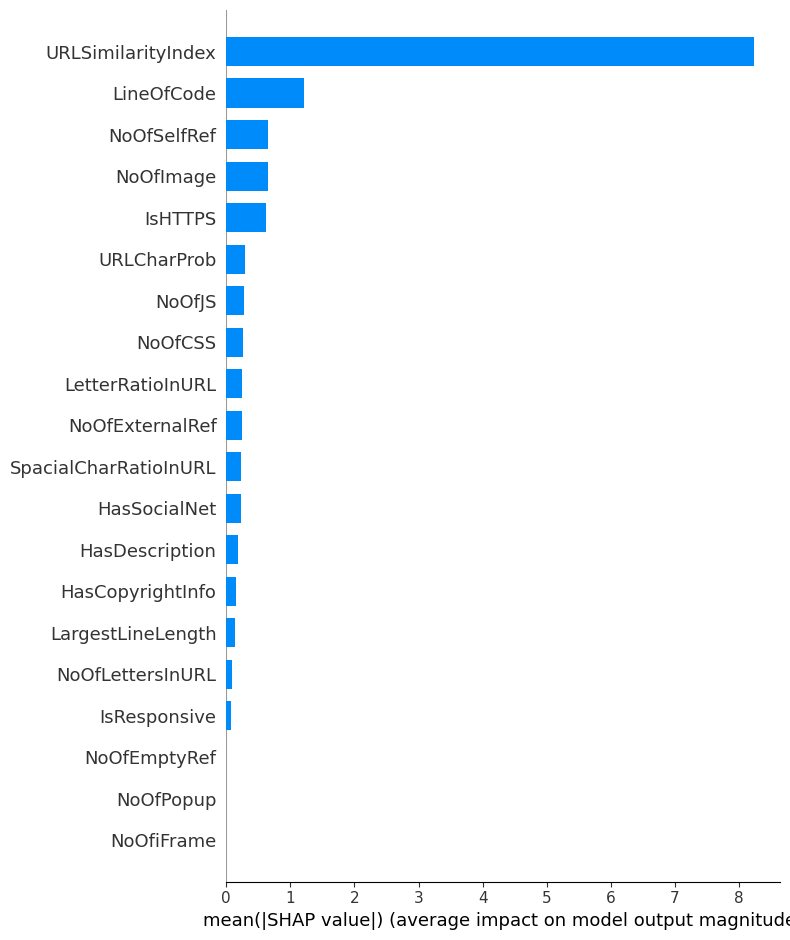

In [8]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

# Single URL Explanation

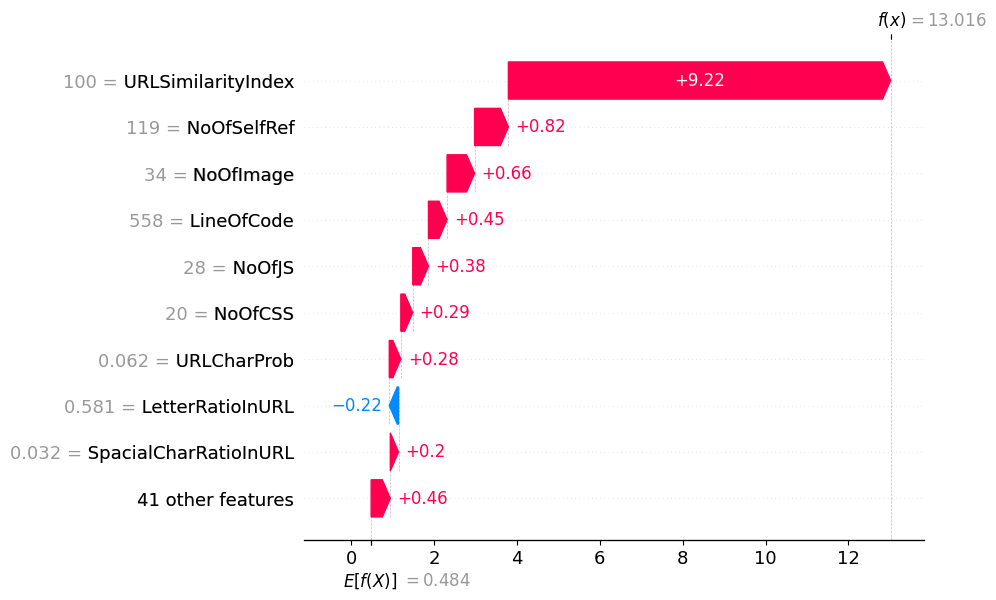

In [9]:
sample = X.iloc[[0]]

shap_values_single = explainer.shap_values(sample)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=X.columns
    )
)

In [11]:
# Prepare SHAP explanation for LLM

sample = X.iloc[[0]]

sample_shap = explainer.shap_values(sample)

shap_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP Value": sample_shap[0],
    "Feature Value": sample.iloc[0].values
})

shap_df["Absolute SHAP"] = shap_df["SHAP Value"].abs()

top_features = shap_df.sort_values(
    by="Absolute SHAP",
    ascending=False
).head(10)

top_features

,Feature,SHAP Value,Feature Value,Absolute SHAP
3,URLSimilarityIndex,9.221221,100.000000,9.221221
47,NoOfSelfRef,0.815379,119.000000,0.815379
44,NoOfImage,0.663791,34.000000,0.663791
22,LineOfCode,0.449122,558.000000,0.449122
46,NoOfJS,0.379259,28.000000,0.379259
45,NoOfCSS,0.287426,20.000000,0.287426
6,URLCharProb,0.278276,0.061933,0.278276
13,LetterRatioInURL,-0.222718,0.581000,0.222718
20,SpacialCharRatioInURL,0.198000,0.032000,0.198000
49,NoOfExternalRef,0.196399,124.000000,0.196399


## Preparing SHAP Evidence for LLM

The SHAP analysis identifies the features that contribute most strongly to the XGBoost prediction.

To connect the Explainable AI module with the LLM module, the most important SHAP features are converted into a structured format. This information will later be provided to the LLM as evidence for generating a simple and human-readable explanation.

The LLM will not perform the phishing classification. The XGBoost model remains responsible for the prediction, while SHAP provides the supporting feature-level evidence.

In [12]:
# XGBoost prediction for the selected URL

prediction = xgb.predict(sample)[0]
probability = xgb.predict_proba(sample)[0][1]

print("Prediction:", "Phishing" if prediction == 1 else "Legitimate")
print("Phishing Probability:", f"{probability:.2%}")

Prediction: Phishing
Phishing Probability: 100.00%


## Extract Top SHAP Features

The top contributing features are extracted based on their absolute SHAP values.

These features represent the strongest factors influencing the selected prediction and will be used as evidence for the LLM explanation.

In [13]:
top_features

,Feature,SHAP Value,Feature Value,Absolute SHAP
3,URLSimilarityIndex,9.221221,100.000000,9.221221
47,NoOfSelfRef,0.815379,119.000000,0.815379
44,NoOfImage,0.663791,34.000000,0.663791
22,LineOfCode,0.449122,558.000000,0.449122
46,NoOfJS,0.379259,28.000000,0.379259
45,NoOfCSS,0.287426,20.000000,0.287426
6,URLCharProb,0.278276,0.061933,0.278276
13,LetterRatioInURL,-0.222718,0.581000,0.222718
20,SpacialCharRatioInURL,0.198000,0.032000,0.198000
49,NoOfExternalRef,0.196399,124.000000,0.196399


## Create Structured SHAP Evidence

The prediction, phishing probability, and top SHAP features are combined into a structured representation.

This structured evidence will act as the input for the LLM module in the next phase.

In [14]:
llm_evidence = {
    "prediction": "Phishing" if prediction == 1 else "Legitimate",
    "phishing_probability": float(probability),
    "top_features": top_features[
        ["Feature", "SHAP Value", "Feature Value"]
    ].to_dict("records")
}

llm_evidence

{'prediction': 'Phishing',
 'phishing_probability': 0.9999977350234985,
 'top_features': [{'Feature': 'URLSimilarityIndex',
   'SHAP Value': 9.221220970153809,
   'Feature Value': 100.0},
  {'Feature': 'NoOfSelfRef',
   'SHAP Value': 0.81537926197052,
   'Feature Value': 119.0},
  {'Feature': 'NoOfImage',
   'SHAP Value': 0.6637913584709167,
   'Feature Value': 34.0},
  {'Feature': 'LineOfCode',
   'SHAP Value': 0.4491221010684967,
   'Feature Value': 558.0},
  {'Feature': 'NoOfJS',
   'SHAP Value': 0.3792590796947479,
   'Feature Value': 28.0},
  {'Feature': 'NoOfCSS',
   'SHAP Value': 0.2874261736869812,
   'Feature Value': 20.0},
  {'Feature': 'URLCharProb',
   'SHAP Value': 0.2782759368419647,
   'Feature Value': 0.061933179},
  {'Feature': 'LetterRatioInURL',
   'SHAP Value': -0.22271820902824402,
   'Feature Value': 0.581},
  {'Feature': 'SpacialCharRatioInURL',
   'SHAP Value': 0.1979997754096985,
   'Feature Value': 0.032},
  {'Feature': 'NoOfExternalRef',
   'SHAP Value': 0.19

## Save SHAP Evidence

The structured SHAP evidence is saved as a JSON file so that it can be loaded by the LLM module without retraining the XGBoost model or recalculating the SHAP analysis.

This creates a clear separation between the Explainable AI and LLM components.

In [15]:
import json

with open("../models/shap_llm_evidence.json", "w") as f:
    json.dump(llm_evidence, f, indent=4)

print("SHAP evidence saved successfully!")

SHAP evidence saved successfully!


## Conclusion

SHAP was successfully implemented using SHAP TreeExplainer to explain the
predictions generated by the XGBoost phishing detection model.

Both global and local interpretability were explored. SHAP summary plots
were used to identify the most influential features across the dataset,
while a waterfall plot was used to explain the contribution of individual
features for a selected URL prediction.

The top contributing features, along with the XGBoost prediction and
phishing probability, were extracted and stored as structured SHAP
evidence.

This evidence forms the connection between the Explainable AI and LLM
modules. The XGBoost model remains responsible for phishing
classification, SHAP provides feature-level evidence, and the LLM
converts this technical evidence into a simple, user-friendly explanation.